# Project 4: Data Visualization
### E-Commerce Orders Dataset
**Name:** Sadikshya Karki  
**Internship:** DecodeLabs Data Science and Analytics | Batch 2026  
**Tool:** Python (matplotlib, seaborn)

---
This notebook focuses on creating clear and meaningful visualizations from the e-commerce orders dataset to communicate key business insights through storytelling with data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')

In [2]:
df_raw = pd.read_excel('Dataset_for_Data_Analytics.xlsx')
df = df_raw.copy()
df['CouponCode'] = df['CouponCode'].fillna('No Coupon')
df['Month'] = df['Date'].dt.to_period('M')
print(f'Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns')
df.head()

Dataset loaded: 1200 rows, 15 columns


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,Month
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10,2023-01
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70,2024-08
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40,2024-02
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19,2023-10
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04,2025-05


## Chart 1: Order Status Distribution (Pie Chart)
**Story:** How many orders are actually reaching customers?

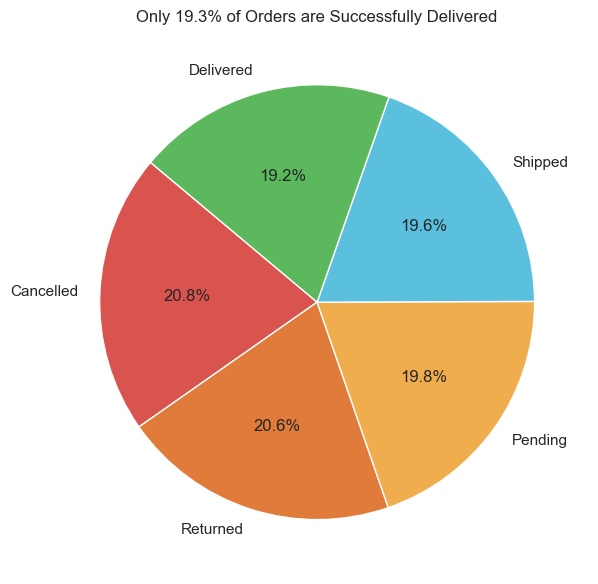

In [13]:
# Pie chart - order status
status = df['OrderStatus'].value_counts()
plt.figure(figsize=(8, 6))
plt.pie(status.values, labels=status.index, autopct='%1.1f%%', startangle=140,
        colors=['#d9534f','#e07b39','#f0ad4e','#5bc0de','#5cb85c'])
plt.title('Only 19.3% of Orders are Successfully Delivered')
plt.tight_layout()
plt.savefig("chart1.png", dpi=150, bbox_inches="tight")
plt.show()

## Chart 2: Revenue by Referral Source (Horizontal Bar Chart)
**Story:** Which channel brings the most revenue, not just orders?

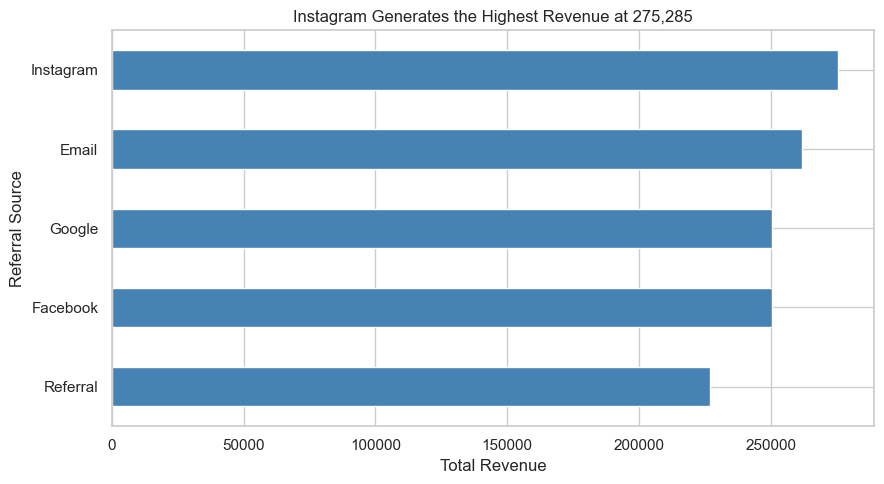

In [14]:
# Horizontal bar - referral source by revenue
df.groupby('ReferralSource')['TotalPrice'].sum().sort_values().plot(kind='barh', color='steelblue', edgecolor='white', figsize=(9, 5))
plt.title('Instagram Generates the Highest Revenue at 275,285')
plt.xlabel('Total Revenue')
plt.ylabel('Referral Source')
plt.tight_layout()
plt.savefig("chart2.png", dpi=150, bbox_inches="tight")
plt.show()

## Chart 3: Monthly Revenue Trend (Line Chart)
**Story:** How has revenue changed month to month?

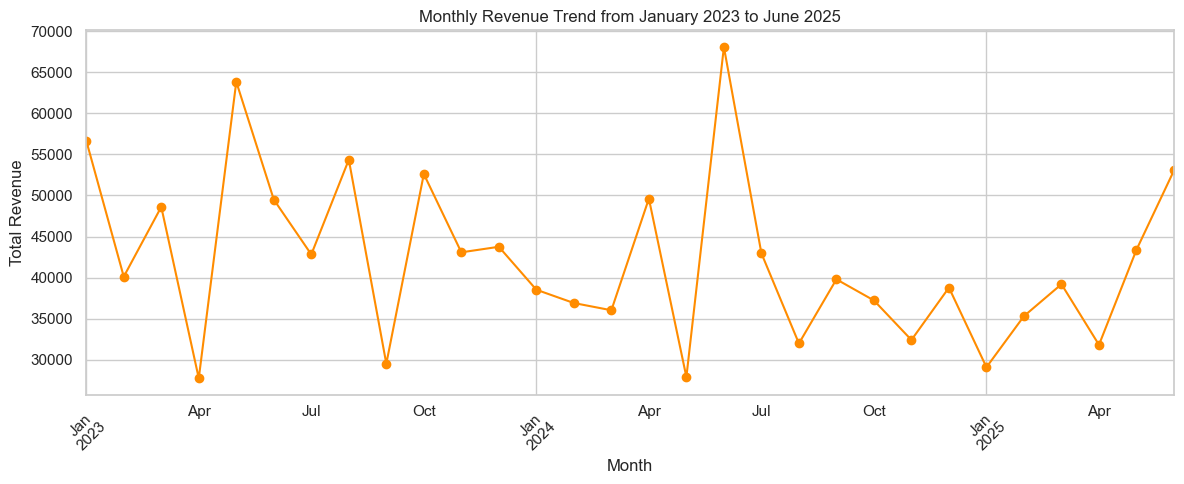

In [15]:
# Line chart - monthly revenue
monthly_rev = df.groupby('Month')['TotalPrice'].sum()
monthly_rev.plot(kind='line', color='darkorange', marker='o', figsize=(12, 5))
plt.title('Monthly Revenue Trend from January 2023 to June 2025')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("chart3.png", dpi=150, bbox_inches="tight")
plt.show()

## Chart 4: Order Status by Product (Stacked Bar Chart)
**Story:** Which products have the most problematic order statuses?

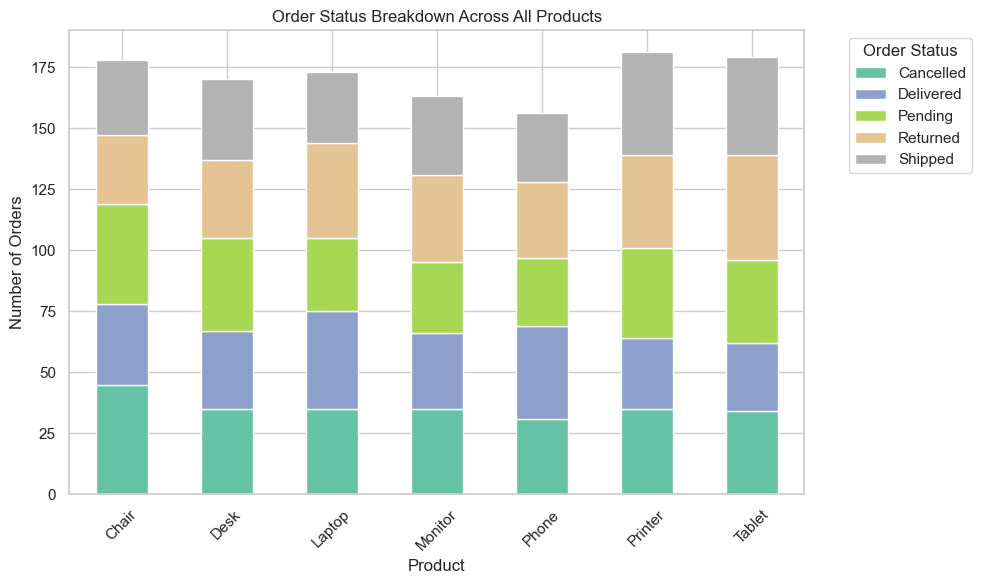

In [16]:
# Stacked bar - order status by product
df.groupby(['Product','OrderStatus']).size().unstack().plot(kind='bar', stacked=True, figsize=(10, 6),
    colormap='Set2', edgecolor='white')
plt.title('Order Status Breakdown Across All Products')
plt.xlabel('Product')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.legend(title='Order Status', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.savefig("chart4.png", dpi=150, bbox_inches="tight")
plt.show()

## Chart 5: TotalPrice Distribution by Product (Box Plot)
**Story:** Which products have the widest price spread and most outliers?

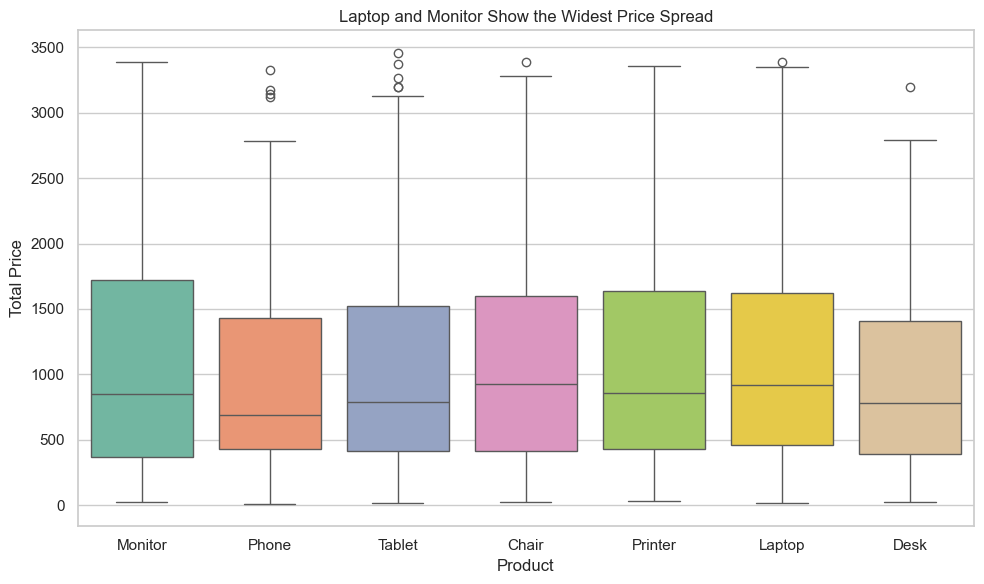

In [17]:
# Box plot - TotalPrice by product
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Product', y='TotalPrice', palette='Set2')
plt.title('Laptop and Monitor Show the Widest Price Spread')
plt.xlabel('Product')
plt.ylabel('Total Price')
plt.tight_layout()
plt.savefig("chart5.png", dpi=150, bbox_inches="tight")
plt.show()

## Chart 6: UnitPrice vs TotalPrice (Scatter Plot)
**Story:** Does a higher unit price always mean a higher total order value?

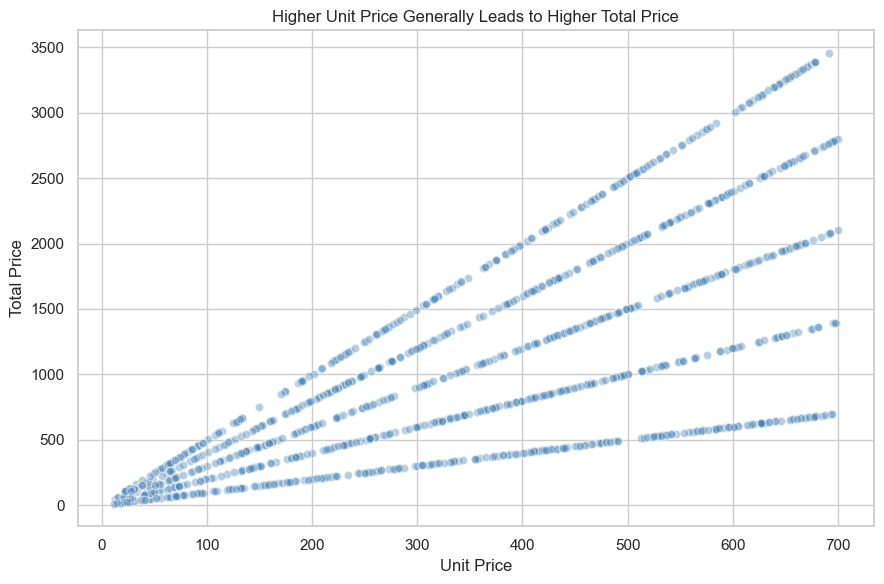

In [18]:
# Scatter plot - UnitPrice vs TotalPrice
plt.figure(figsize=(9, 6))
plt.scatter(df['UnitPrice'], df['TotalPrice'], alpha=0.4, color='steelblue', edgecolor='white')
plt.title('Higher Unit Price Generally Leads to Higher Total Price')
plt.xlabel('Unit Price')
plt.ylabel('Total Price')
plt.tight_layout()
plt.savefig("chart6.png", dpi=150, bbox_inches="tight")
plt.show()

## Chart 7: Monthly Revenue Area Chart
**Story:** How does revenue accumulate and fluctuate over time?

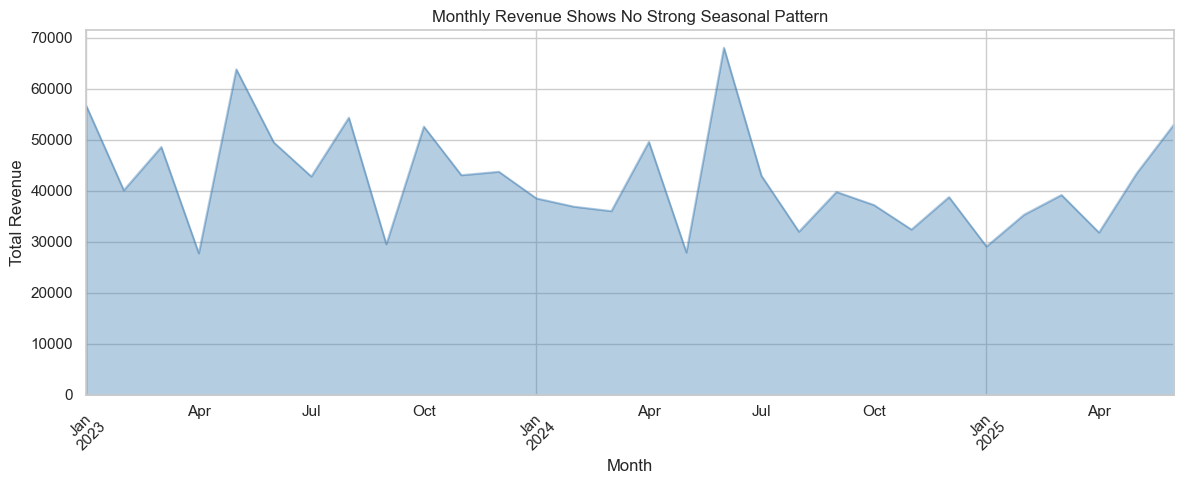

In [19]:
# Area chart - monthly revenue
monthly_rev = df.groupby('Month')['TotalPrice'].sum()
monthly_rev.plot(kind='area', color='steelblue', alpha=0.4, figsize=(12, 5))
plt.title('Monthly Revenue Shows No Strong Seasonal Pattern')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("chart7.png", dpi=150, bbox_inches="tight")
plt.show()

## Chart 8: Revenue by Payment Method (Bar Chart)
**Story:** Which payment method drives the most business value?

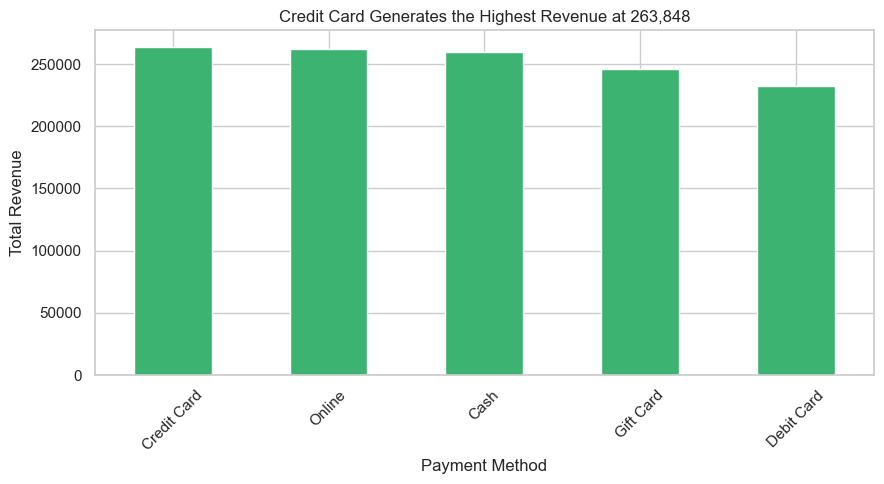

In [20]:
# Bar chart - revenue by payment method
df.groupby('PaymentMethod')['TotalPrice'].sum().sort_values(ascending=False).plot(kind='bar', color='mediumseagreen', edgecolor='white', figsize=(9, 5))
plt.title('Credit Card Generates the Highest Revenue at 263,848')
plt.xlabel('Payment Method')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("chart8.png", dpi=150, bbox_inches="tight")
plt.show()

## Chart 9: Coupon Code Usage (Donut Chart)
**Story:** How are customers using discount coupons?

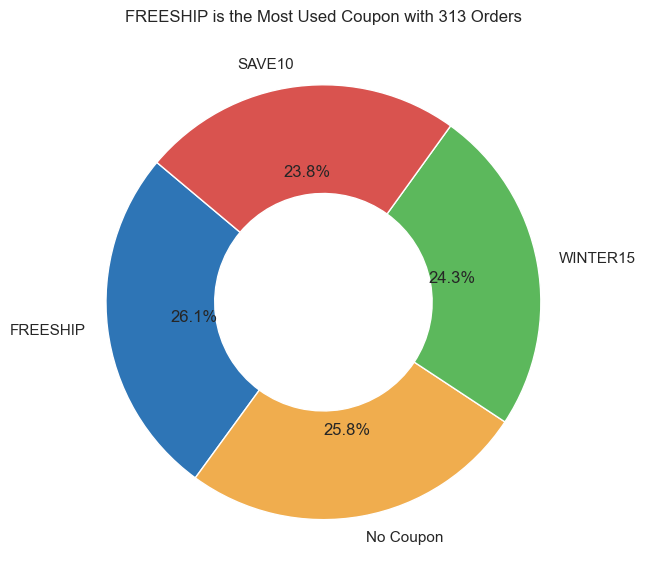

In [21]:
# Donut chart - coupon usage
coupon = df['CouponCode'].value_counts()
fig, ax = plt.subplots(figsize=(8, 6))
ax.pie(coupon.values, labels=coupon.index, autopct='%1.1f%%', startangle=140,
       colors=['#2E75B6','#f0ad4e','#5cb85c','#d9534f'],
       wedgeprops=dict(width=0.5))
ax.set_title('FREESHIP is the Most Used Coupon with 313 Orders')
plt.tight_layout()
plt.savefig("chart9.png", dpi=150, bbox_inches="tight")
plt.show()

## Chart 10: Cancelled vs Delivered Orders by Product (Grouped Bar Chart)
**Story:** Which products have the worst fulfillment performance?

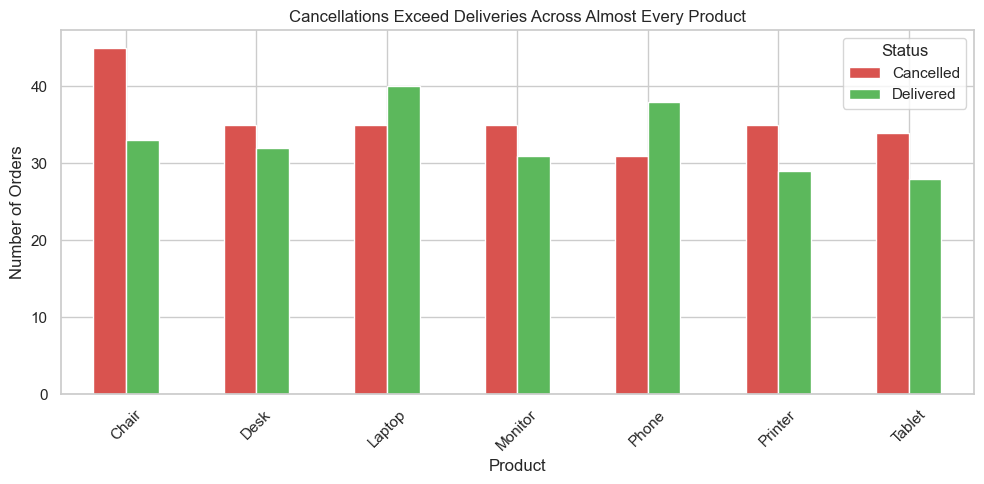

In [22]:
# Grouped bar - cancelled vs delivered
status_product = df[df['OrderStatus'].isin(['Delivered','Cancelled'])].groupby(['Product','OrderStatus']).size().unstack()
status_product.plot(kind='bar', color=['#d9534f','#5cb85c'], edgecolor='white', figsize=(10, 5))
plt.title('Cancellations Exceed Deliveries Across Almost Every Product')
plt.xlabel('Product')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.legend(title='Status')
plt.tight_layout()
plt.savefig("chart10.png", dpi=150, bbox_inches="tight")
plt.show()

## Summary of Key Visual Insights

| Chart | Type | Key Insight |
|-------|------|-------------|
| Chart 1 | Pie | Only 19.3% of orders delivered; 41.4% cancelled or returned |
| Chart 2 | Horizontal Bar | Instagram generates the highest revenue at 275,285 |
| Chart 3 | Line | Monthly revenue fluctuates with no strong seasonal pattern |
| Chart 4 | Stacked Bar | Every product has high cancellation and return volumes |
| Chart 5 | Box Plot | Laptop and Monitor show the widest price spread |
| Chart 6 | Scatter | Higher unit price generally leads to higher total price |
| Chart 7 | Area | Revenue accumulation shows consistent but uneven growth |
| Chart 8 | Bar | Credit Card drives the most revenue at 263,848 |
| Chart 9 | Donut | FREESHIP is the most popular coupon at 34.8% usage |
| Chart 10 | Grouped Bar | Cancellations exceed deliveries for almost every product |

---
**Overall Story:** The business has a balanced product mix and strong marketing channels, but the high cancellation and return rate of 41.4% is a critical issue that needs urgent attention.